In [1]:
# -*- coding: utf-8 -*-
"""
@author: Hiromasa Kaneko　https://github.com/hkaneko1985/python_doe_kspub.
Modified by Masanori Kodera　https://github.com/masanorikodera
"""

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, KFold, cross_val_predict
from sklearn.gaussian_process import GaussianProcessRegressor # GPR モデル構築に使用
from sklearn.gaussian_process.kernels import WhiteKernel, RBF, ConstantKernel, Matern, DotProduct
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import seaborn as sns

In [4]:
import sys
import sklearn
print("Python:", sys.version)
print("scikit-learn:", sklearn.__version__)

Python: 3.11.9 | packaged by conda-forge | (main, Apr 19 2024, 18:27:10) [MSC v.1938 64 bit (AMD64)]
scikit-learn: 1.6.0


In [2]:
#dataset = pd.read_csv('dataset_allregion.csv', index_col=0, header=0)
dataset = pd.read_csv('dataset_region1.csv', index_col=0, header=0)
print(dataset.head())
dataset.shape

           mass  nit temp  nit time  NH3 flow rate  mass-based DoN
sample ID                                                         
T7          0.5      1123      10.0            2.0        66.20393
T15         1.0      1123      25.0            2.0        83.64706
T22         0.5      1123       0.0            2.0         6.62966
T23         0.5      1123       5.0            2.0        35.55002
T28         0.5      1173       5.0            2.0        55.77830


(65, 5)

In [3]:
dataset=dataset.dropna()
dataset.shape

(65, 5)

In [4]:
number_of_test_samples = 0 
fold_number = 10  
dataset.head()
#dataset.shape

,mass,nit temp,nit time,NH3 flow rate,mass-based DoN
sample ID,,,,,
T7,0.5,1123,10.0,2.0,66.20393
T15,1.0,1123,25.0,2.0,83.64706
T22,0.5,1123,0.0,2.0,6.62966
T23,0.5,1123,5.0,2.0,35.55002
T28,0.5,1173,5.0,2.0,55.77830


In [5]:
y = dataset.iloc[:, -1]  
x = dataset.iloc[:, 0:-1] 

if number_of_test_samples == 0:
    x_train = x.copy()
    x_test = x.copy()
    y_train = y.copy()
    y_test = y.copy()
else:
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=number_of_test_samples, shuffle=True,
                                                        random_state=123)

deleting_variables = x_train.columns[x_train.std() == 0]
x_train = x_train.drop(deleting_variables, axis=1)
x_test = x_test.drop(deleting_variables, axis=1)

autoscaled_y_train = (y_train - y_train.mean()) / y_train.std()
autoscaled_x_train = (x_train - x_train.mean()) / x_train.std()

In [7]:
# カーネル 11 種類
kernels = [DotProduct() + WhiteKernel(),
           ConstantKernel() * RBF() + WhiteKernel(),
           ConstantKernel() * RBF() + WhiteKernel() + DotProduct(),
           ConstantKernel() * RBF(np.ones(x_train.shape[1])) + WhiteKernel(),
           ConstantKernel() * RBF(np.ones(x_train.shape[1])) + WhiteKernel() + DotProduct(),
           ConstantKernel() * Matern(nu=1.5) + WhiteKernel(),
           ConstantKernel() * Matern(nu=1.5) + WhiteKernel() + DotProduct(),
           ConstantKernel() * Matern(nu=2.5) + WhiteKernel(),
           ConstantKernel() * Matern(nu=2.5) + WhiteKernel() + DotProduct()]



In [11]:
optimal_kernel = kernels[2] 

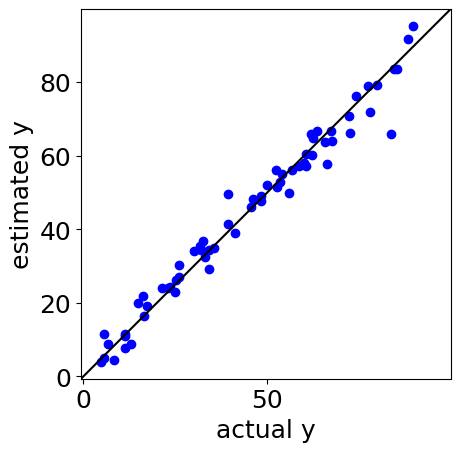

r^2 for training data : 0.9730592569570979
RMSE for training data : 3.9911042729226622
MAE for training data : 2.8148591156344915


In [12]:
model = GaussianProcessRegressor(alpha=0, kernel=optimal_kernel) 
model.fit(autoscaled_x_train, autoscaled_y_train) 

autoscaled_estimated_y_train, autoscaled_estimated_y_train_std = model.predict(autoscaled_x_train, return_std=True) 
estimated_y_train = autoscaled_estimated_y_train * y_train.std() + y_train.mean()  
estimated_y_train_std = autoscaled_estimated_y_train_std * y_train.std() 
estimated_y_train = pd.DataFrame(estimated_y_train, index=x_train.index, columns=['estimated_y'])
estimated_y_train_std = pd.DataFrame(estimated_y_train_std, index=x_train.index, columns=['std_of_estimated_y'])

plt.rcParams['font.size'] = 18
plt.scatter(y_train, estimated_y_train.iloc[:, 0], c='blue')
y_max = max(y_train.max(), estimated_y_train.iloc[:, 0].max())
y_min = min(y_train.min(), estimated_y_train.iloc[:, 0].min()) 
plt.plot([y_min - 0.05 * (y_max - y_min), y_max + 0.05 * (y_max - y_min)],
         [y_min - 0.05 * (y_max - y_min), y_max + 0.05 * (y_max - y_min)], 'k-') 
plt.ylim(y_min - 0.05 * (y_max - y_min), y_max + 0.05 * (y_max - y_min)) 
plt.xlim(y_min - 0.05 * (y_max - y_min), y_max + 0.05 * (y_max - y_min)) 
plt.xlabel('actual y')  
plt.ylabel('estimated y') 
plt.gca().set_aspect('equal', adjustable='box') 
plt.show()

print('r^2 for training data :', r2_score(y_train, estimated_y_train))
print('RMSE for training data :', np.sqrt(mean_squared_error(y_train, estimated_y_train)))
print('MAE for training data :', mean_absolute_error(y_train, estimated_y_train))

y_train_for_save = pd.DataFrame(y_train)
y_train_for_save.columns = ['actual_y']
y_error_train = y_train_for_save.iloc[:, 0] - estimated_y_train.iloc[:, 0]
y_error_train = pd.DataFrame(y_error_train)
y_error_train.columns = ['error_of_y(actual_y-estimated_y)']
results_train = pd.concat([y_train_for_save, estimated_y_train, y_error_train, estimated_y_train_std], axis=1) 
results_train.to_csv('estimated_y_train_in_detail_gpr_kernels.csv') 

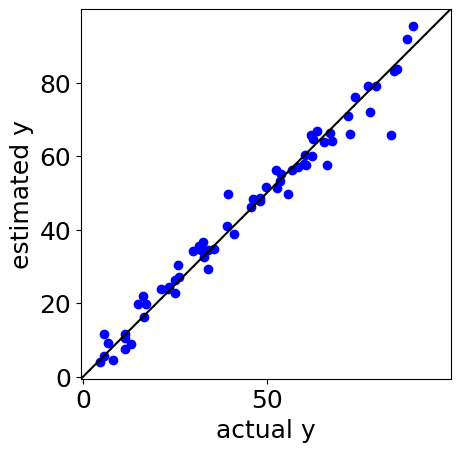

r^2 for test data : 0.9725997711737344
RMSE for test data : 4.024995364055583
MAE for test data : 2.85162358890525


In [10]:
autoscaled_x_test = (x_test - x_train.mean()) / x_train.std()

autoscaled_estimated_y_test, autoscaled_estimated_y_test_std = model.predict(autoscaled_x_test, return_std=True) 
estimated_y_test = autoscaled_estimated_y_test * y_train.std() + y_train.mean()  
estimated_y_test_std = autoscaled_estimated_y_test_std * y_train.std()  
estimated_y_test = pd.DataFrame(estimated_y_test, index=x_test.index, columns=['estimated_y'])
estimated_y_test_std = pd.DataFrame(estimated_y_test_std, index=x_test.index, columns=['std_of_estimated_y'])

plt.rcParams['font.size'] = 18
plt.scatter(y_test, estimated_y_test.iloc[:, 0], c='blue') 
y_max = max(y_test.max(), estimated_y_test.iloc[:, 0].max()) 
y_min = min(y_test.min(), estimated_y_test.iloc[:, 0].min()) 
plt.plot([y_min - 0.05 * (y_max - y_min), y_max + 0.05 * (y_max - y_min)],
         [y_min - 0.05 * (y_max - y_min), y_max + 0.05 * (y_max - y_min)], 'k-')  
plt.ylim(y_min - 0.05 * (y_max - y_min), y_max + 0.05 * (y_max - y_min))  
plt.xlim(y_min - 0.05 * (y_max - y_min), y_max + 0.05 * (y_max - y_min)) 
plt.xlabel('actual y')  
plt.ylabel('estimated y')  
plt.gca().set_aspect('equal', adjustable='box')  
plt.show()  

# テストデータのr2, RMSE, MAE
print('r^2 for test data :', r2_score(y_test, estimated_y_test))
print('RMSE for test data :', np.sqrt(mean_squared_error(y_train, estimated_y_train)))
print('MAE for test data :', mean_absolute_error(y_test, estimated_y_test))

y_test_for_save = pd.DataFrame(y_test)
y_test_for_save.columns = ['actual_y']
y_error_test = y_test_for_save.iloc[:, 0] - estimated_y_test.iloc[:, 0]
y_error_test = pd.DataFrame(y_error_test)
y_error_test.columns = ['error_of_y(actual_y-estimated_y)']
results_test = pd.concat([y_test_for_save, estimated_y_test, y_error_test, estimated_y_test_std], axis=1) # 結合
results_test.to_csv('estimated_y_test_in_detail_gpr_kernels.csv')  